# This notebook can be ignored. This is just creating visualizations/diagrams for my paper :)

In [ ]:
import pandas as pd
import os
import numpy as np
from datetime import datetime, timedelta
import pytz
from IPython.display import display
from datetime import datetime
import cv2
from google.colab.patches import cv2_imshow
import pickle

In [ ]:
CECS_698_PATH = '/content/drive/MyDrive/CECS 698 - Data Analysis/'

EMBRACEPLUS_TRIMMED_PATH = os.path.join(CECS_698_PATH, 'EmbracePlus Trimmed')
EMBRACEPLUS_COMBINED_PATH = os.path.join(CECS_698_PATH, 'EmbracePlus Combined')

GAZEPOINT_TRIMMED_PATH = os.path.join(CECS_698_PATH, 'Gazepoint Trimmed')

PARTICIPANTS = [i for i in range(4, 27)]

GAZEPOINT_TUMBLING_WINDOW_DGM = os.path.join(CECS_698_PATH, 'Gazepoint Tumbling Window DGM')
GAZEPOINT_DGM_TIMESTAMP_LABELED = os.path.join(CECS_698_PATH, 'Gazepoint DGM Timestamp Labeled')

MERGED_DATA = os.path.join(CECS_698_PATH, 'Merged Data')

# Particpants ids to exclude on specific assessments
EASY_ASSESSMENT_EXCLUDE = [11, 22]
HARD_ASSESSMENT_EXCLUDE = [15, 21]

# Demonstraing Algorithm on how the 2 tables merge

In [ ]:
p = 16
diff = 'hard'

descriptive_gaze_measures = pd.read_csv(os.path.join(GAZEPOINT_DGM_TIMESTAMP_LABELED, f'Participant {p}', f'all_gaze_{diff}.csv'))
descriptive_gaze_measures = descriptive_gaze_measures[['timestamp_unix'] + [col for col in descriptive_gaze_measures.columns if col != 'timestamp_unix']]
descriptive_gaze_measures.drop(columns=['window'], inplace=True)
descriptive_gaze_measures['timestamp_unix'] = descriptive_gaze_measures['timestamp_unix'].astype('int64')


# Number of columns to display from the start and end
n_cols = 2  # Adjust as needed

descriptive_gaze_measures = pd.concat([
    descriptive_gaze_measures.iloc[:, :n_cols],  # First few columns
    pd.DataFrame({f"...": ["..."] * len(descriptive_gaze_measures)}),  # Placeholder
    descriptive_gaze_measures.iloc[:, -n_cols:]  # Last few columns
], axis=1).head(10)


biomarkers = pd.read_csv(os.path.join(EMBRACEPLUS_COMBINED_PATH, f'Participant {p}', f'EmbracePlus_{diff}_combined.csv')).head(5)

In [ ]:
biomarker_cols = [col for col in biomarkers.columns if col != 'timestamp_unix']
DGM_cols = [col for col in descriptive_gaze_measures.columns if col != 'timestamp_unix']

In [ ]:
# Function to color df1 (blue) and df2 (green)
def highlight_df1(val):
    return 'background-color: lightblue; color: black;'

def highlight_df2(val):
    return 'background-color: lightgreen; color: black;'

In [ ]:
biomarkers_styled = biomarkers.style.applymap(highlight_df1)
descriptive_gaze_measures_styled = descriptive_gaze_measures.style.applymap(highlight_df2)

<ipython-input-56-b9c324860e33>:1: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  biomarkers_styled = biomarkers.style.applymap(highlight_df1)
<ipython-input-56-b9c324860e33>:2: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  descriptive_gaze_measures_styled = descriptive_gaze_measures.style.applymap(highlight_df2)


In [ ]:
pacific_tz = pytz.timezone('America/Los_Angeles')

In [ ]:
start_timestamp = biomarkers['timestamp_unix'].iloc[0]
start_timestamp = datetime.utcfromtimestamp(start_timestamp / 1000).replace(tzinfo=pytz.utc).astimezone(pacific_tz).isoformat() # Convert to datetime (UTC)

end_timestamp = biomarkers['timestamp_unix'].iloc[-1]
end_timestamp = datetime.utcfromtimestamp(end_timestamp / 1000).replace(tzinfo=pytz.utc).astimezone(pacific_tz).isoformat() # Convert to datetime (UTC)


# Print result
print(f"BIOMARKERS: {start_timestamp} - {end_timestamp}")


biomarkers_styled

BIOMARKERS: 2024-12-12T11:38:00-08:00 - 2024-12-12T11:42:00-08:00


,timestamp_unix,eda_scl_usiemens,pulse_rate_bpm,temperature_celsius
0,1734032280000,0.330000,82.000000,29.450000
1,1734032340000,0.350000,81.000000,29.560000
2,1734032400000,0.370000,81.000000,29.620000
3,1734032460000,0.360000,82.000000,29.660000
4,1734032520000,0.360000,81.000000,29.670000


In [ ]:
start_timestamp = descriptive_gaze_measures['timestamp_unix'].iloc[0]
start_timestamp = datetime.utcfromtimestamp(start_timestamp / 1000).replace(tzinfo=pytz.utc).astimezone(pacific_tz).isoformat() # Convert to datetime (UTC)

end_timestamp = descriptive_gaze_measures['timestamp_unix'].iloc[-1]
end_timestamp = datetime.utcfromtimestamp(end_timestamp / 1000).replace(tzinfo=pytz.utc).astimezone(pacific_tz).isoformat() # Convert to datetime (UTC)


# Print result
print(f"BIOMARKERS: {start_timestamp} - {end_timestamp}")

descriptive_gaze_measures_styled

BIOMARKERS: 2024-12-12T11:37:57.332000-08:00 - 2024-12-12T11:39:27.332000-08:00


,timestamp_unix,total_number_of_fixations,...,average_pupil_size_of_right_eye,average_pupil_size_of_both_eyes
0,1734032277332,35.000000,...,2.743261,2.718871
1,1734032287332,38.000000,...,2.780543,2.747521
2,1734032297328,37.000000,...,2.802790,2.734552
3,1734032307328,31.000000,...,2.751706,2.683613
4,1734032317332,25.000000,...,2.866622,2.825294
5,1734032327328,31.000000,...,2.862976,2.832390
6,1734032337328,37.000000,...,2.759951,2.717594
7,1734032347332,33.000000,...,2.767632,2.734372
8,1734032357332,24.000000,...,2.973396,2.930461
9,1734032367332,43.000000,...,2.778398,2.777216


Inner Join

In [ ]:
merged = pd.merge(biomarkers,
                  descriptive_gaze_measures,
                  on="timestamp_unix",
                  how="inner")


# Function to highlight value_A and value_B with different colors
def highlight_merged(row):
    styles = []
    for col in merged.columns:
        if col in biomarker_cols:
            styles.append('background-color: lightblue; color: black;')
        elif col in DGM_cols:
            styles.append('background-color: lightgreen; color: black;')
        else:
            styles.append('')  # No color for timestamp
    return styles

# Apply styling to the merged DataFrame
merged_styled = merged.style.apply(highlight_merged, axis=1)

# Display the styled merged DataFrame
display(merged_styled)

,timestamp_unix,eda_scl_usiemens,pulse_rate_bpm,temperature_celsius,total_number_of_fixations,...,average_pupil_size_of_right_eye,average_pupil_size_of_both_eyes


Outer Join

In [ ]:
merged = pd.merge(biomarkers,
                  descriptive_gaze_measures,
                  on="timestamp_unix",
                  how="outer")


# Function to highlight value_A and value_B with different colors
def highlight_merged(row):
    styles = []
    for col in merged.columns:
        if col in biomarker_cols:
            styles.append('background-color: lightblue; color: black;')
        elif col in DGM_cols:
            styles.append('background-color: lightgreen; color: black;')
        else:
            styles.append('')  # No color for timestamp
    return styles

# Apply styling to the merged DataFrame
merged_styled = merged.style.apply(highlight_merged, axis=1)

# Display the styled merged DataFrame
display(merged_styled)

,timestamp_unix,eda_scl_usiemens,pulse_rate_bpm,temperature_celsius,total_number_of_fixations,...,average_pupil_size_of_right_eye,average_pupil_size_of_both_eyes
0,1734032277332,nan,nan,nan,35.000000,...,2.743261,2.718871
1,1734032280000,0.330000,82.000000,29.450000,nan,nan,nan,nan
2,1734032287332,nan,nan,nan,38.000000,...,2.780543,2.747521
3,1734032297328,nan,nan,nan,37.000000,...,2.802790,2.734552
4,1734032307328,nan,nan,nan,31.000000,...,2.751706,2.683613
5,1734032317332,nan,nan,nan,25.000000,...,2.866622,2.825294
6,1734032327328,nan,nan,nan,31.000000,...,2.862976,2.832390
7,1734032337328,nan,nan,nan,37.000000,...,2.759951,2.717594
8,1734032340000,0.350000,81.000000,29.560000,nan,nan,nan,nan
9,1734032347332,nan,nan,nan,33.000000,...,2.767632,2.734372


Outer join with interpolate

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

# Merge the two DataFrames
merged = pd.merge(biomarkers,
                  descriptive_gaze_measures,
                  on="timestamp_unix",
                  how="outer").interpolate(method='linear')# Apply linear interpolation

# Sort by timestamp to ensure proper interpolation
# merged = merged.sort_values(by="timestamp_unix")


# Function to highlight merged values
def highlight_merged(row):
    styles = []
    for col in merged.columns:
        if col in biomarker_cols:
            styles.append('background-color: lightblue; color: black;')
        elif col in DGM_cols:
            styles.append('background-color: lightgreen; color: black;')
        else:
            styles.append('')  # No color for timestamp
    return styles


merged['...'].fillna('...', inplace=True)

# Apply styling to the interpolated DataFrame
merged_styled = merged.style.apply(highlight_merged, axis=1)

# Display the styled merged DataFrame
display(merged_styled)


<ipython-input-78-4d4cb7abdbb1>:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  how="outer").interpolate(method='linear')# Apply linear interpolation
<ipython-input-78-4d4cb7abdbb1>:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged['...'].fillna('...', inplace=True)


,timestamp_unix,eda_scl_usiemens,pulse_rate_bpm,temperature_celsius,total_number_of_fixations,...,average_pupil_size_of_right_eye,average_pupil_size_of_both_eyes
0,1734032277332,nan,nan,nan,35.000000,...,2.743261,2.718871
1,1734032280000,0.330000,82.000000,29.450000,36.500000,...,2.761902,2.733196
2,1734032287332,0.332857,81.857143,29.465714,38.000000,...,2.780543,2.747521
3,1734032297328,0.335714,81.714286,29.481429,37.000000,...,2.802790,2.734552
4,1734032307328,0.338571,81.571429,29.497143,31.000000,...,2.751706,2.683613
5,1734032317332,0.341429,81.428571,29.512857,25.000000,...,2.866622,2.825294
6,1734032327328,0.344286,81.285714,29.528571,31.000000,...,2.862976,2.832390
7,1734032337328,0.347143,81.142857,29.544286,37.000000,...,2.759951,2.717594
8,1734032340000,0.350000,81.000000,29.560000,35.000000,...,2.763792,2.725983
9,1734032347332,0.355000,81.000000,29.575000,33.000000,...,2.767632,2.734372


In [ ]:
def is_timestamp_increasing(df=merged):
    """
    Checks if the timestamps in the given column are in increasing order.

    Parameters:
    - df: pandas DataFrame
    - timestamp_col: str, name of the timestamp column

    Returns:
    - True if timestamps are strictly increasing, False otherwise
    """
    return df['timestamp_unix'].is_monotonic_increasing

is_timestamp_increasing(merged)

True

# Images (FPOG plots)

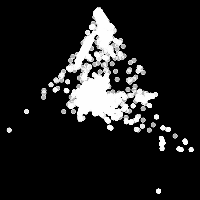

In [ ]:
# Load the image
image = cv2.imread('/content/drive/MyDrive/CECS 698 - Data Analysis/FPOG Scanpaths/Participant 10/FPOG easy.png')  # Replace 'image.jpg' with your file path
resized_image = cv2.resize(image, (200, 200))  # Change (600, 400) to desired dimensions

# Display the image
cv2_imshow(resized_image)

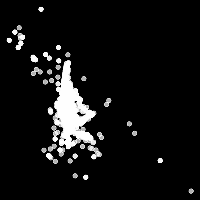

In [ ]:
# Load the image
image = cv2.imread('/content/drive/MyDrive/CECS 698 - Data Analysis/FPOG Scanpaths/Participant 16/FPOG hard.png')  # Replace 'image.jpg' with your file path
resized_image = cv2.resize(image, (200, 200))  # Change (600, 400) to desired dimensions

# Display the image
cv2_imshow(resized_image)

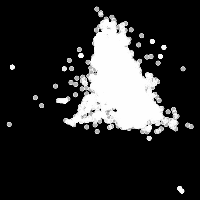

In [ ]:
# Load the image
image = cv2.imread('/content/drive/MyDrive/CECS 698 - Data Analysis/FPOG Scanpaths/Participant 8/FPOG easy.png')  # Replace 'image.jpg' with your file path
resized_image = cv2.resize(image, (200, 200))  # Change (600, 400) to desired dimensions

# Display the image
cv2_imshow(resized_image)

# Model history

In [ ]:
import os
import pickle
import matplotlib.pyplot as plt

# Load model history from a file
def load_history(filepath):
    with open(filepath, 'rb') as file:
        return pickle.load(file)

# Function to plot all model histories with customizable colors
def plot_all_histories(histories, colors=('tab:blue', 'tab:orange')):

    # Create a figure with subplots for each model
    fig, axes = plt.subplots(len(histories), 2, figsize=(12, 5 * len(histories)))  # 2 columns: Accuracy and Loss

    # Loop through each model history and plot it
    for i, (title, filename) in enumerate(histories.items()):
        history_path = os.path.join(model_history, filename)
        history = load_history(history_path)

        train_color, val_color = colors  # Unpack color scheme

        # Plot Accuracy
        axes[i, 0].plot(history.history['accuracy'], label='Train Accuracy', color=train_color)
        axes[i, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', color=val_color)
        axes[i, 0].set_xlabel('Epochs')
        axes[i, 0].set_ylabel('Accuracy')
        axes[i, 0].set_title(f"{title} - Accuracy")
        axes[i, 0].legend()

        # Plot Loss
        axes[i, 1].plot(history.history['loss'], label='Train Loss', color=train_color)
        axes[i, 1].plot(history.history['val_loss'], label='Validation Loss', color=val_color)
        axes[i, 1].set_xlabel('Epochs')
        axes[i, 1].set_ylabel('Loss')
        axes[i, 1].set_title(f"{title} - Loss")
        axes[i, 1].legend()

    # Adjust layout and show the figure
    plt.tight_layout()
    plt.show()

In [ ]:
saved_models = os.path.join(CECS_698_PATH, 'Saved Models')
if not os.path.exists(saved_models):
    print(f"{saved_models} does not exist")
else:
    print(f"{saved_models} already exists")

model_history = os.path.join(saved_models, 'Model History')
if not os.path.exists(model_history):
    print(f"{model_history} does not exist")
else:
    print(f"{model_history} already exists")

/content/drive/MyDrive/CECS 698 - Data Analysis/Saved Models already exists
/content/drive/MyDrive/CECS 698 - Data Analysis/Saved Models/Model History already exists


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 20 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables wher

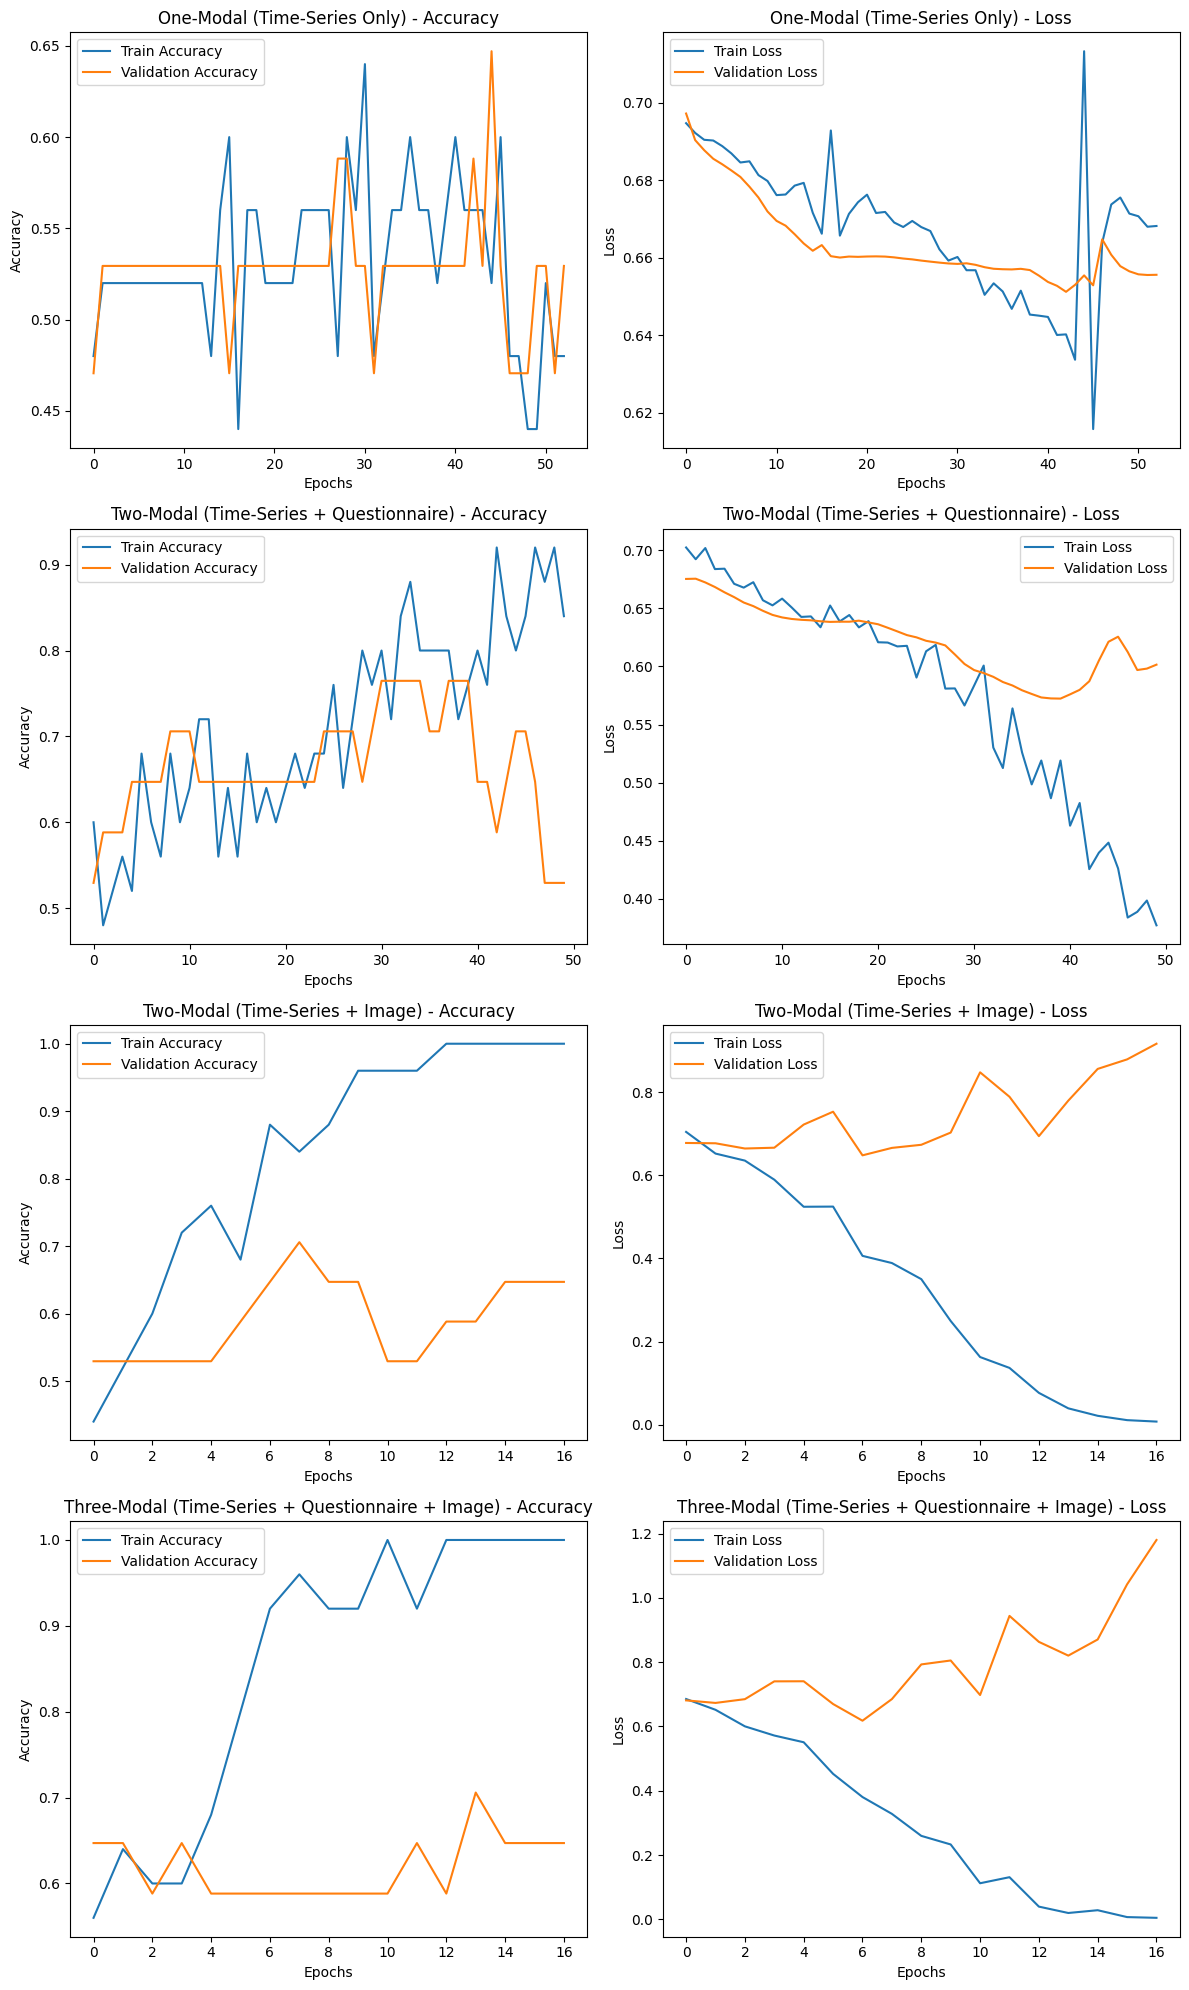

In [ ]:
# Define the model history files and their corresponding labels
histories = {
    "One-Modal (Time-Series Only)": 'one-modal-ts.pkl',
    "Two-Modal (Time-Series + Questionnaire)": 'two-modal-ts-q.pkl',
    "Two-Modal (Time-Series + Image)": 'two-modal-ts-img.pkl',
    "Three-Modal (Time-Series + Questionnaire + Image)": 'three-modal.pkl'
}

plot_all_histories(histories)

In [ ]:
saved_models = os.path.join(CECS_698_PATH, 'Saved Models 2')
if not os.path.exists(saved_models):
    print(f"{saved_models} does not exist")
else:
    print(f"{saved_models} already exists")

model_history = os.path.join(saved_models, 'Model History')
if not os.path.exists(model_history):
    print(f"{model_history} does not exist")
else:
    print(f"{model_history} already exists")

/content/drive/MyDrive/CECS 698 - Data Analysis/Saved Models 2 already exists
/content/drive/MyDrive/CECS 698 - Data Analysis/Saved Models 2/Model History already exists


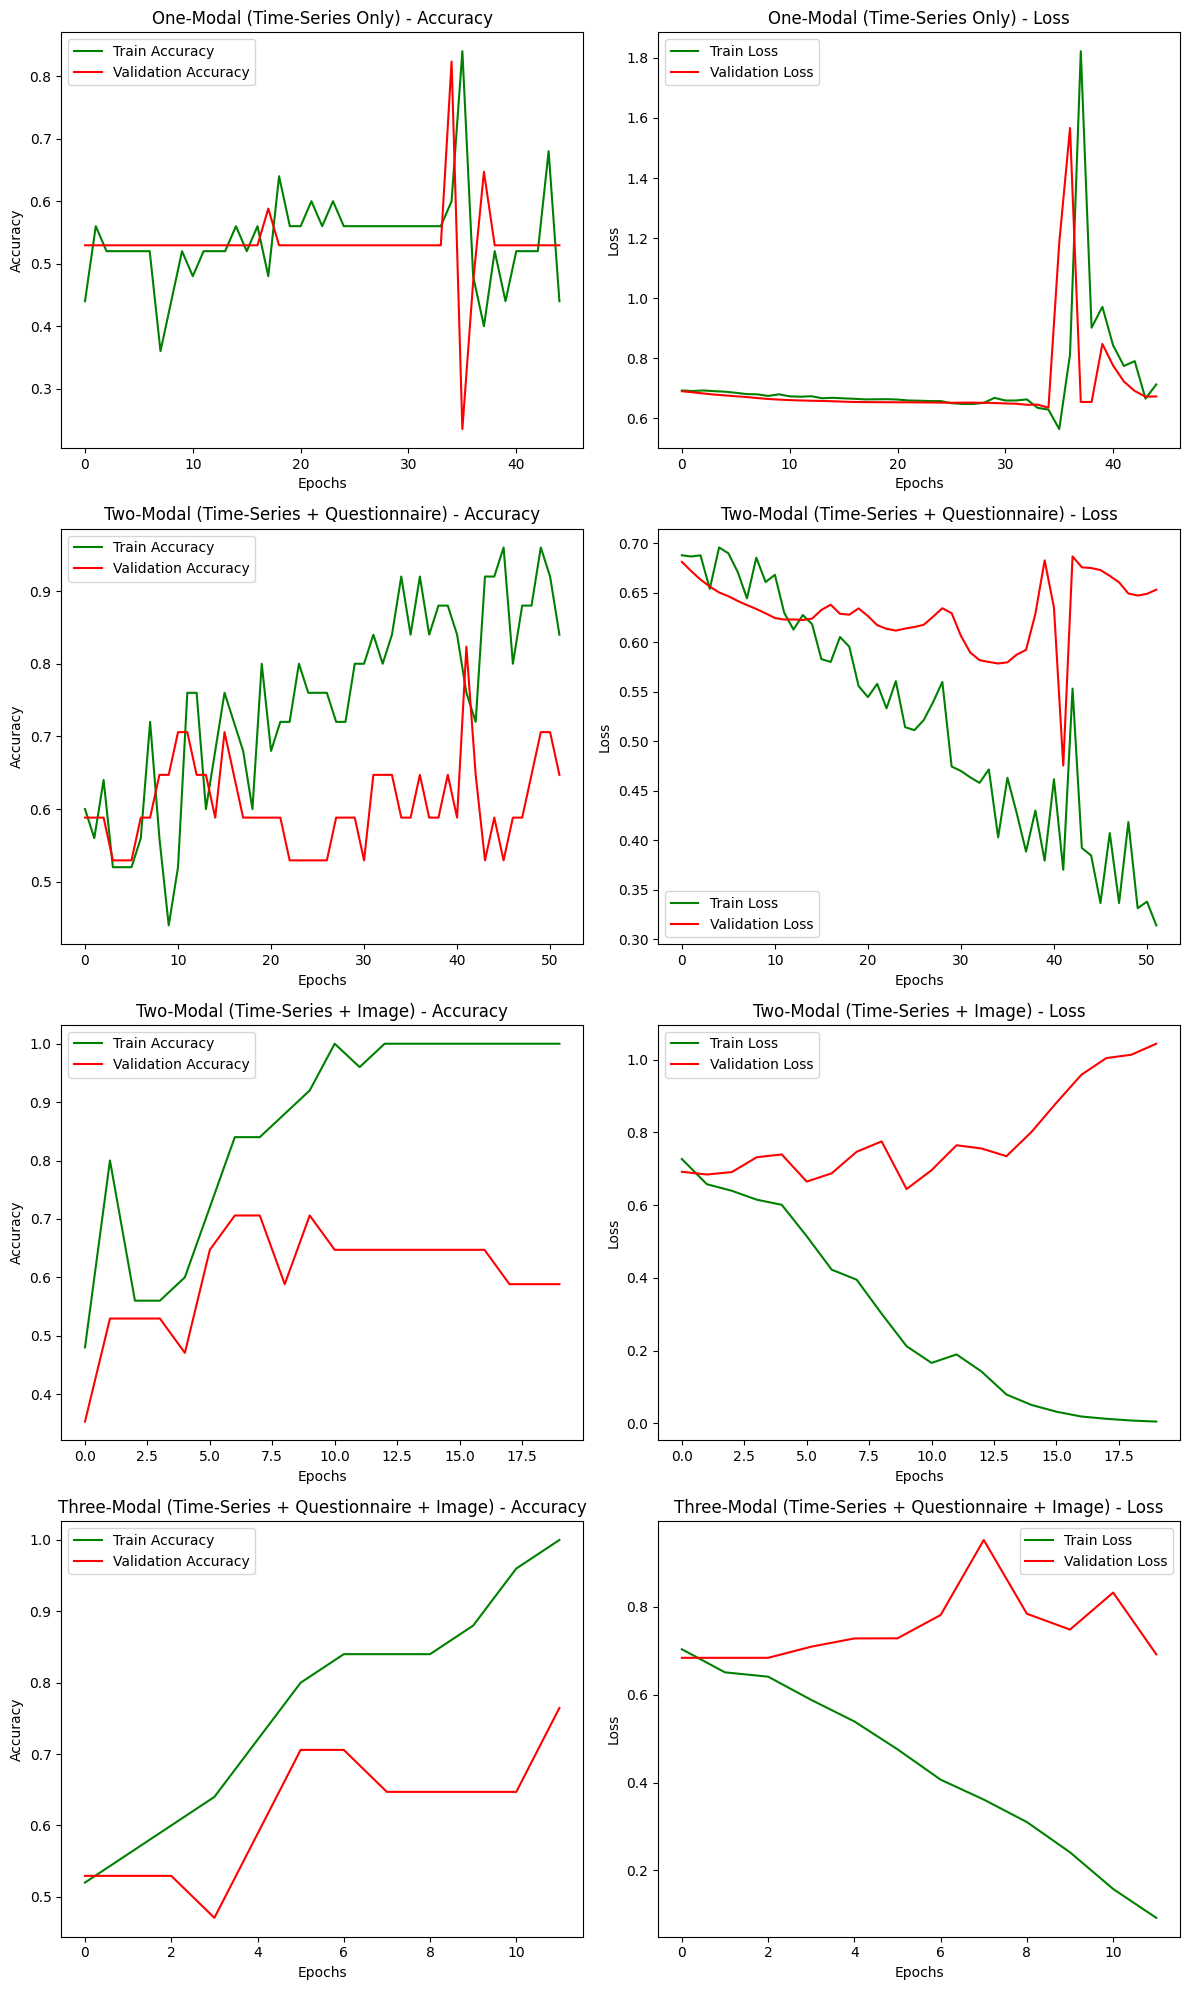

In [ ]:
# Define the model history files and their corresponding labels
suffix = 'exclude-biomarkers'
histories = {
    "One-Modal (Time-Series Only)": f'one-modal-ts-{suffix}.pkl',
    "Two-Modal (Time-Series + Questionnaire)": f'two-modal-ts-q-{suffix}.pkl',
    "Two-Modal (Time-Series + Image)": f'two-modal-ts-img-{suffix}.pkl',
    "Three-Modal (Time-Series + Questionnaire + Image)": f'three-modal-{suffix}.pkl'
}

plot_all_histories(histories, colors=('green', 'red'))

# List all columns for Appendix C

In [38]:
cols = pd.read_csv('/content/drive/MyDrive/CECS 698 - Data Analysis/Merged Data/Participant 10/participant10_easy_assessment.csv').columns.tolist()
cols.remove('timestamp_unix')

In [40]:
pd.DataFrame(cols)

,0
0,eda_scl_usiemens
1,pulse_rate_bpm
2,temperature_celsius
3,total_number_of_fixations
4,sum_of_all_fixation_duration_s
...,...
59,average_blink_rate_per_minute
60,total_number_of_valid_recordings
61,average_pupil_size_of_left_eye
62,average_pupil_size_of_right_eye


In [41]:

pd.DataFrame(cols).to_csv(os.path.join(CECS_698_PATH, 'all_cols.csv'), index=False)